In [1]:
import pandas as pd

import os
import s3fs


fs = s3fs.S3FileSystem(
    client_kwargs={'endpoint_url': 'https://'+'minio.lab.sspcloud.fr'},
    key = os.environ["AWS_ACCESS_KEY_ID"], 
    secret = os.environ["AWS_SECRET_ACCESS_KEY"], 
    token = os.environ["AWS_SESSION_TOKEN"])

"""
with fs.open("s3://lab/art_net_dec.parquet") as f : 
    dfa = pd.read_parquet(f)



with fs.open("s3://lab/conf_net_dec.parquet") as f : 
    dfc = pd.read_parquet(f)"""

#with fs.open("s3://lab/mem/full_name_list.csv") as f : 
   # nl = pd.read_csv(f, index_col=[0])
"""
with fs.open("s3://lab/mem/n_to_g.csv") as f : 
    ntg = pd.read_csv(f, index_col=[0])"""
"""
with fs.open("s3://lab/kgnd.csv") as f:
    kgnd = pd.read_csv(f)
with fs.open("s3://lab/ignd.csv") as f:
    ignd = pd.read_csv(f)
with fs.open("s3://lab/wgnd.csv") as f:
    wgnd = pd.read_csv(f)
with fs.open("s3://lab/jgnd.csv") as f:
    jgnd = pd.read_csv(f)
with fs.open("s3://lab/cgnd.csv") as f:
    cgnd = pd.read_csv(f)
with fs.open("s3://lab/usgnd.csv") as f: 
    usgnd = pd.read_csv(f)"""

'\nwith fs.open("s3://lab/kgnd.csv") as f:\n    kgnd = pd.read_csv(f)\nwith fs.open("s3://lab/ignd.csv") as f:\n    ignd = pd.read_csv(f)\nwith fs.open("s3://lab/wgnd.csv") as f:\n    wgnd = pd.read_csv(f)\nwith fs.open("s3://lab/jgnd.csv") as f:\n    jgnd = pd.read_csv(f)\nwith fs.open("s3://lab/cgnd.csv") as f:\n    cgnd = pd.read_csv(f)\nwith fs.open("s3://lab/usgnd.csv") as f: \n    usgnd = pd.read_csv(f)'

ATTR df

In [13]:
import pandas as pd
with fs.open("s3://lab/wgnd.csv") as f:
    wgnd = pd.read_csv(f)

wgnd = wgnd.rename(columns={"Name":"name", "Gender" : "gender"})
wgnd = wgnd.drop_duplicates()
wgnd

,name,gender
0,baby,F
1,aisyah,F
2,anela,F
4,fiyinfoluwa,F
6,olioni,M
...,...,...
21831032,hyihwa,F
21831033,hyihwan,M
21831034,hyihun,M
21831037,hiyori,F


In [3]:
with fs.open("s3://lab/art_net_dec.parquet") as f : 
    dfa = pd.read_parquet(f)
dfa

,title,journal,year,authors,dblp_uri,doi
0,Auswirkung der Digitalisierung auf die Systeml...,Elektrotech. Informationstechnik,2019,"[{'name': 'Kai Schlabitz', 'orcid': None}]",journals/ei/Schlabitz19,https://doi.org/10.1007/s00502-019-0687-y
1,EMF-Personenschutz: Neue Aspekte in der numeri...,Elektrotech. Informationstechnik,2020,"[{'name': 'Richard Überbacher', 'orcid': None}...",journals/ei/UberbacherC20,https://doi.org/10.1007/s00502-020-00791-z
2,Zur Genesis der Forschungsstelle für Integrier...,Elektrotech. Informationstechnik,2022,"[{'name': 'Herbert Mang', 'orcid': None}]",journals/ei/Mang22,https://doi.org/10.1007/s00502-022-01049-6
3,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,"[{'name': 'Sophie Knöttner', 'orcid': None}, {...",journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7
4,Application of multilateration for microphone ...,Elektrotech. Informationstechnik,2021,[],journals/ei/WimbergerR21,https://doi.org/10.1007/s00502-021-00885-2
...,...,...,...,...,...,...
3992218,"Derivability, Redundancy and Consistency of Re...","Research Report / RJ / IBM / San Jose, California",1969,"[{'name': 'E. F. Codd', 'orcid': None}]",persons/Codd69,None
3992219,Normalized Data Base Structure: A Brief Tutorial.,"Research Report / RJ / IBM / San Jose, California",1971,"[{'name': 'E. F. Codd', 'orcid': None}]",persons/Codd71b,None
3992220,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,"[{'name': 'Gayane Grigoryan', 'orcid': None}, ...",persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217
3992221,Common Subexpression Identification in General...,"Technical Rep. UKSC 0060, IBM United Kingdom S...",1974,"[{'name': 'Patrick A. V. Hall', 'orcid': None}]",persons/Hall74,None


In [4]:
#to etract citations

dfa["citations"] = pd.NA

for i in range(1,407):
    with fs.open(f"s3://lab/cite/dblp_{i}.csv") as f:
        temp = pd.read_csv(f)
    temp["dblp_uri"] = temp["dblp_uri"].str.replace(
        "https://dblp.org/rec/", "", regex=False
    )
    temp_map = (
        temp.drop_duplicates("dblp_uri")
          .set_index("dblp_uri")["citations"]
    )
    
    dfa["citations"] = (
        dfa["citations"]
        .combine_first(dfa["dblp_uri"].map(temp_map))
    )

/tmp/ipykernel_7130/4097367981.py:18: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  .combine_first(dfa["dblp_uri"].map(temp_map))


In [5]:
dfa["authors"] = dfa["authors"].apply(lambda lst: [d["name"] for d in lst])
attr = dfa.explode("authors")
attr = attr.groupby("authors", as_index=False).agg({col: list for col in attr.columns if col != "authors"})

In [6]:
import re, string

attr["name"] = attr["authors"].str.split(" ").str[0].str.lower()
punct = re.escape(string.punctuation)
attr["name"] = attr["name"].str.replace(f'[{punct}]', '', regex=True)

In [17]:
attr = attr.merge(wgnd,how="left",on="name")
attr

,authors,title,journal,year,dblp_uri,doi,citations,name,gender
0,'Damola Adediji,"[Undermining competition, undermining markets?...",[Big Data Soc.],[2025],[journals/bigdatasociety/BirchA25],[None],[nan],damola,M
1,'Maseka Lesaoana,[A transportation branch and bound algorithm f...,"[Int. J. Syst. Assur. Eng. Manag., Oper. Res.]","[2015, 2001]","[journals/saem/MunapoLNK15, journals/ior/HallL...","[https://doi.org/10.1007/s13198-015-0343-9, ht...","[8.0, 70.0]",maseka,NaN
2,'Osaiasi Lolohea,[Visual literacy shown through a magnifying le...,[Interact. Technol. Smart Educ.],[2023],[journals/itse/ReddySCLT23],[https://doi.org/10.1108/ITSE-01-2022-0007],[2.0],osaiasi,NaN
3,(David) Jing Dai,[AutonomousGIS 2017 workshop report: the First...,[ACM SIGSPATIAL Special],[2017],[journals/sigspatial/GaoDHXC17],[https://doi.org/10.1145/3178392.3178407],[nan],david,M
4,(Max) Zong-Ming Cheng,[MicroSyn: A user friendly tool for detection ...,"[BMC Bioinform., BMC Bioinform.]","[2011, 2009]","[journals/bmcbi/CaiYTC11, journals/bmcbi/XuZHZ...","[https://www.wikidata.org/entity/Q28741346, ht...","[35.0, 186.0]",max,M
...,...,...,...,...,...,...,...,...,...
2700980,Þorsteinn Sæmundsson,[Inferring 2D Local Surface-Deformation Veloci...,[Remote. Sens.],[2022],[journals/remotesensing/DittrichHTS22],[None],[4.0],þorsteinn,NaN
2700981,Þröstur Pétursson,[Bone Mineral Density and Fracture Risk Assess...,[Comput. Math. Methods Medicine],[2015],[journals/cmmm/PeturssonEGMMHJ15],[https://www.wikidata.org/entity/Q36055821],[21.0],þröstur,NaN
2700982,Þórhildur Þorleiksdóttir,[Exquisitor: Interactive Learning at Large.],[CoRR],[2019],[journals/corr/abs-1904-08689],[None],[nan],þórhildur,NaN
2700983,Þórir Hrafn Harðarson,[Aligning Language Models for Icelandic Legal ...,[CoRR],[2025],[journals/corr/abs-2504-18180],[None],[nan],þórir,NaN


In [18]:
import numpy as np

attr["max_cite"] = attr["citations"].apply(np.max)

attr["mean_cite"] = attr["citations"].apply(np.mean)

In [22]:
attr.to_parquet("s3://lab/mem/art_attr.parquet")

EDGES df

In [28]:
from itertools import combinations

rows = []
for _, row in dfa.iterrows():
    for sender, receiver in combinations(row["authors"], 2):
        new_row = row.to_dict()
        new_row["sender"] = sender
        new_row["receiver"] = receiver
        rows.append(new_row)

edges_df = pd.DataFrame(rows).drop(columns=["authors"])

In [ ]:
with fs.open("s3://lab/CORE_journals_corr.csv") as f : 
    rank = pd.read_csv(f)

edges_df = edges_df.merge(rank[["abrv","rank"]], left_on="journal",right_on="abrv",how="left")

In [21]:
edges_df.to_parquet("s3://lab/mem/art_edges.parquet")

In [ ]:
# NA
len(attr[attr["gender"].isna()])/len(attr)

0.09237476842307255

Network modelisation

In [22]:
import pandas as pd
with fs.open("s3://lab/mem/art_edges.parquet") as f : 
    edges = pd.read_parquet(f)

edges

,title,journal,year,dblp_uri,doi,citations,sender,receiver,abrv,rank
0,EMF-Personenschutz: Neue Aspekte in der numeri...,Elektrotech. Informationstechnik,2020,journals/ei/UberbacherC20,https://doi.org/10.1007/s00502-020-00791-z,NaN,Richard Überbacher,Stefan Cecil,None,None
1,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7,NaN,Sophie Knöttner,Roman Geyer,None,None
2,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7,NaN,Sophie Knöttner,Christian Diendorfer,None,None
3,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7,NaN,Sophie Knöttner,Gerwin H. S. Drexler-Schmid,None,None
4,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7,NaN,Roman Geyer,Christian Diendorfer,None,None
...,...,...,...,...,...,...,...,...,...,...
17676648,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217,25.0,Oliver Gronz,Rita Ley,None,None
17676649,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217,25.0,Oliver Gronz,Andreas Rock,None,None
17676650,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217,25.0,Oliver Gutjahr,Rita Ley,None,None
17676651,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217,25.0,Oliver Gutjahr,Andreas Rock,None,None


In [13]:
with fs.open("s3://lab/mem/art_attr.parquet") as f : 
    attr = pd.read_parquet(f)

attr

,authors,title,journal,year,dblp_uri,doi,citations,name,gender,max_cite,mean_cite
0,'Damola Adediji,"[Undermining competition, undermining markets?...",[Big Data Soc.],[2025],[journals/bigdatasociety/BirchA25],[None],[nan],damola,M,NaN,NaN
1,'Maseka Lesaoana,[A transportation branch and bound algorithm f...,"[Int. J. Syst. Assur. Eng. Manag., Oper. Res.]","[2015, 2001]","[journals/saem/MunapoLNK15, journals/ior/HallL...","[https://doi.org/10.1007/s13198-015-0343-9, ht...","[8.0, 70.0]",maseka,None,70.0,39.0
2,'Osaiasi Lolohea,[Visual literacy shown through a magnifying le...,[Interact. Technol. Smart Educ.],[2023],[journals/itse/ReddySCLT23],[https://doi.org/10.1108/ITSE-01-2022-0007],[2.0],osaiasi,None,2.0,2.0
3,(David) Jing Dai,[AutonomousGIS 2017 workshop report: the First...,[ACM SIGSPATIAL Special],[2017],[journals/sigspatial/GaoDHXC17],[https://doi.org/10.1145/3178392.3178407],[nan],david,M,NaN,NaN
4,(Max) Zong-Ming Cheng,[MicroSyn: A user friendly tool for detection ...,"[BMC Bioinform., BMC Bioinform.]","[2011, 2009]","[journals/bmcbi/CaiYTC11, journals/bmcbi/XuZHZ...","[https://www.wikidata.org/entity/Q28741346, ht...","[35.0, 186.0]",max,M,186.0,110.5
...,...,...,...,...,...,...,...,...,...,...,...
2700980,Þorsteinn Sæmundsson,[Inferring 2D Local Surface-Deformation Veloci...,[Remote. Sens.],[2022],[journals/remotesensing/DittrichHTS22],[None],[4.0],þorsteinn,None,4.0,4.0
2700981,Þröstur Pétursson,[Bone Mineral Density and Fracture Risk Assess...,[Comput. Math. Methods Medicine],[2015],[journals/cmmm/PeturssonEGMMHJ15],[https://www.wikidata.org/entity/Q36055821],[21.0],þröstur,None,21.0,21.0
2700982,Þórhildur Þorleiksdóttir,[Exquisitor: Interactive Learning at Large.],[CoRR],[2019],[journals/corr/abs-1904-08689],[None],[nan],þórhildur,None,NaN,NaN
2700983,Þórir Hrafn Harðarson,[Aligning Language Models for Icelandic Legal ...,[CoRR],[2025],[journals/corr/abs-2504-18180],[None],[nan],þórir,None,NaN,NaN


In [31]:
%pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 84.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [23]:
edges = edges[edges["year"].astype(int)>1980]

In [ ]:
for _, row in edges_df.iterrows():
    G.add_edge(
        row["sender"], row["receiver"],
        year=row["year"],
        rank=row["rank"],
        citations=row["citations"]
    )

In [ ]:
import networkx as nx

G = nx.Graph()

for _, row in edges.iterrows():
    G.add_edge(
        row["sender"], row["receiver"],
        year=row["year"],
        rank=row["rank"],
        citations=row["citations"]
    )

for _, row in attr[["authors","gender","mean_cite"]].iterrows():
    if row["authors"] in G.nodes:
        G.nodes[row["authors"]].update(row.to_dict())

KeyError: 'authors'

In [26]:
G.remove_edges_from(nx.selfloop_edges(G))

In [27]:
graphs = list(nx.connected_components(G))

3 graphs à plus de 50 membres → on retient que le premier graph et les autres sont considérés comme des teams ? nn on garde que le gros

In [28]:
big_graphs = []

for i in graphs : 
    if len(i)>50 : 
        big_graphs.append(i)
len(big_graphs)

3

In [29]:
core = G.subgraph(graphs[0]).copy()

In [39]:
import pickle

# Save
with fs.open("s3://lab/mem/core_graph.pkl", "wb") as f:
    pickle.dump(core, f)

In [38]:
u, v, d = list(core.edges(data=True))[0]
print(u, v, d)

Richard Überbacher Stefan Cecil {'year': '2020', 'rank': None, 'citations': nan}


identifier les commu

In [3]:
import pickle
with fs.open("s3://lab/mem/core_graph.pkl", "rb") as f:
    core = pickle.load(f)

In [ ]:
import networkx as nx

degree_dict = dict(core.degree())

rc = nx.rich_club_coefficient(core, normalized=False)

NameError: name 'pd' is not defined

In [9]:
import pandas as pd

df_nodes = pd.DataFrame([
    {"name": node, "degree": degree_dict[node], **data}
    for node, data in core.nodes(data=True)
])

df_nodes["rc_coefficient"] = df_nodes["degree"].map(rc)

df_nodes

,name,degree,authors,gender,mean_cite,rc_coefficient
0,Richard Überbacher,1,Richard Überbacher,M,NaN,0.000008
1,Stefan Cecil,5,Stefan Cecil,M,NaN,0.000026
2,Sophie Knöttner,3,Sophie Knöttner,F,NaN,0.000015
3,Roman Geyer,3,Roman Geyer,M,NaN,0.000015
4,Christian Diendorfer,3,Christian Diendorfer,M,NaN,0.000015
...,...,...,...,...,...,...
1863120,Sebastian Mossburger,3,Sebastian Mossburger,M,NaN,0.000015
1863121,Hugo Hellebrand,2,Hugo Hellebrand,M,105.0,0.000011
1863122,Oliver Gronz,4,Oliver Gronz,M,25.0,0.000020
1863123,Oliver Gutjahr,4,Oliver Gutjahr,M,21.0,0.000020


In [12]:
from sklearn.linear_model import LogisticRegression
import statsmodels.formula.api as smf

model = smf.ols("rc_coefficient ~ C(gender, Treatment('M')) + mean_cite + mean_cite:C(gender, Treatment('M'))", data=df_nodes).fit() #F ref bc alphabetic order
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         rc_coefficient   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1180.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:10:10   Log-Likelihood:             2.9852e+06
No. Observations:              628933   AIC:                        -5.970e+06
Df Residuals:                  628929   BIC:                        -5.970e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

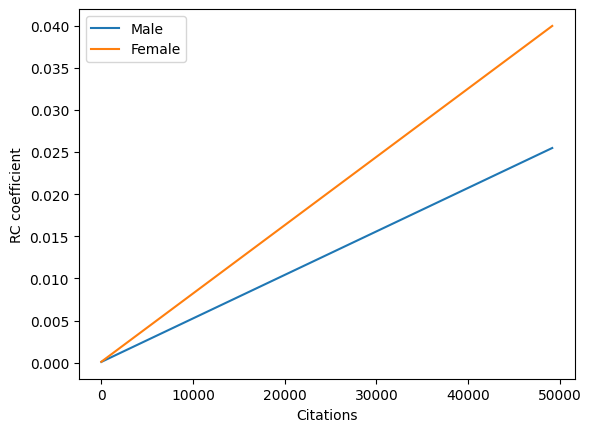

In [14]:
import numpy as np
import matplotlib.pyplot as plt

citations = np.linspace(0, df_nodes["mean_cite"].max(), 100)

rc_male = 0.0001 + 5.161e-07 * citations
rc_female = (0.0001 + 1.977e-05) + (5.161e-07 + 2.941e-07) * citations

plt.plot(citations, rc_male, label="Male")
plt.plot(citations, rc_female, label="Female")
plt.xlabel("Citations")
plt.ylabel("RC coefficient")
plt.legend()

In [ ]:
graphs = []
for year in range(2000, 2024):
    edges = df[df["year"] == year][["source", "target"]].values.tolist()
    g_year = ig.Graph(n=n_nodes, edges=edges)
    graphs.append(g_year)

partition, interslice = leidenalg.find_partition_temporal(
    graphs,
    leidenalg.RBConfigurationVertexPartition,
    interslice_weight=0.1,
    resolution_parameter=2.0
)

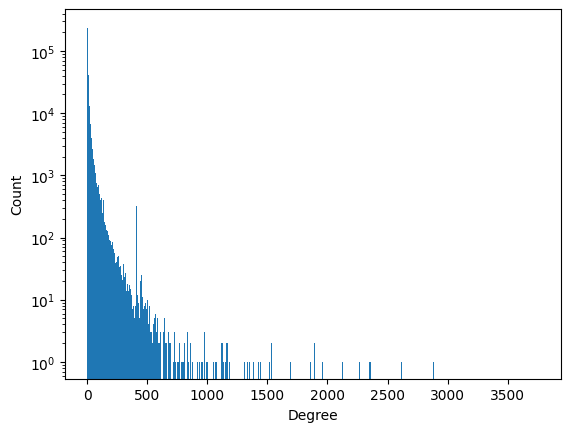

In [48]:
import matplotlib.pyplot as plt
import numpy as np
degree_sequence = sorted((d for n, d in core.degree()), reverse=True)
plt.hist(degree_sequence, bins=range(min(degree_sequence), max(degree_sequence) + 2))
plt.yscale("log")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()

In [43]:
nx.average_node_connectivity(core)

KeyboardInterrupt: 

In [ ]:
nx.flow_hierarchy(core)